__General Workflow for the Gamma Pipeline__


RawSpectrum -->
CalibratedSpectrum -->
EfficiencyCorrectedSpectrum -->
MLEEstimate

In [19]:
### Generic Imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Add repo root (parent of notebooks/) to import path
sys.path.insert(0, str(Path.cwd().parent))

### Gamma Pipeline Import
import gamma

from gamma.artifacts import ArtifactStore
from gamma.io_excel import read_excel_sheet, load_experiment_xls 
from gamma.io_mappings import ExperimentMapping, apply_mapping
from gamma.preprocess import subtract_background, strip_embedded_background
from gamma.aggregate import aggregate_replicates
from gamma.preprocess import subtract_background

In [20]:
### Define Directory to Save Artifacts
store = ArtifactStore("../artifacts") 

In [21]:
### Manually Input Raw Data Filepaths
BOX_DRIVE = r"C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\Box_12-1-2025\134Ce+225Ac-Hidex data_Naidu"

ANIL_DATA = rf"{BOX_DRIVE}\24-0921_Hidex_AcCe-Mixture-Standards-Repeat"

ANIL_CE = rf"{ANIL_DATA}\134Ce_Std_.xlsx"
ANIL_AC = rf"{ANIL_DATA}\225Ac_std.xlsx"
ANIL_MIX = rf"{ANIL_DATA}\Mix_.xlsx"

WENJO_DATA = rf"{BOX_DRIVE}\24-0702_CZT-Hidex-Comparison_(Standards&Mice)\Hidex"
WENJO_CE = rf"{WENJO_DATA}\HidexAMG-134CeLa(89Zr)_std_czt-003-20240705-144014-AutoExport.xlsx"


# Initial Loading 
### (Raw Excel Sheets with Replicate Measurements)

In [22]:
anil_ce_sheet_name = 1

raw_anil_ce_exp = load_experiment_xls(ANIL_CE, 
    sheet_name=anil_ce_sheet_name,
    header=None,
    data_skiprows=19,
    data_usecols=range(2,2050),
    engine='calamine')

wenjo_ce_sheet_name = 1

raw_wenjo_ce_exp = load_experiment_xls(WENJO_CE, 
    sheet_name=wenjo_ce_sheet_name,
    header=None,
    data_skiprows=19,
    data_usecols=range(2,2050),
    engine='calamine')

anil_ac_sheet_name = 1

raw_anil_ac_exp = load_experiment_xls(ANIL_AC, 
    sheet_name=anil_ac_sheet_name,
    header=None,
    data_skiprows=19,
    data_usecols=range(2,2050),
    engine='calamine')

raw_anil_mix_exp = load_experiment_xls(ANIL_MIX, 
    sheet_name=anil_ac_sheet_name,
    header=None,
    data_skiprows=19,
    data_usecols=range(2,2050),
    engine='calamine')

In [23]:
### Just for viz
anil_ce_sheet = read_excel_sheet(ANIL_CE, 
    sheet_name=anil_ce_sheet_name,
    header=None,
    skiprows=19,
    usecols=range(2,2050),
    engine='calamine')

display(anil_ce_sheet)

,2,3,4,5,6,7,8,9,10,11,...,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049
0,24427,6455,3084,1863,319,282,268,278,300,333,...,0,0,0,0,0,0,0,0,0,0
1,25314,6721,3208,1929,318,272,255,264,296,337,...,0,0,0,0,0,0,0,0,0,0
2,24892,6614,3146,1889,306,261,246,259,291,335,...,0,0,0,0,0,0,0,0,0,0
3,6759,274,187,141,94,74,65,68,107,121,...,0,0,0,0,0,0,0,0,0,0
4,6378,274,182,148,101,70,68,71,91,109,...,0,0,0,0,0,0,0,0,0,0
5,6125,244,163,155,113,68,65,62,84,98,...,0,0,0,0,0,0,0,0,0,0
6,1970,157,86,86,45,21,26,29,32,44,...,0,0,0,0,0,0,0,0,0,0
7,1956,156,81,63,44,33,16,25,43,49,...,0,0,0,0,0,0,0,0,0,0
8,1864,128,72,58,35,25,27,29,40,40,...,0,0,0,0,0,0,0,0,0,0
9,748,90,36,33,19,16,9,18,13,18,...,0,0,0,0,0,0,0,0,0,0


# Define Mapping
### (Define mapping between order of measurements and label)

In [24]:
#### Anil_Ce 

anil_ce_activities = [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125]
anil_ce_n_reps = 3

anil_ce_labels = [f"{a:g}_rep{r}" for a in anil_ce_activities for r in range(1, anil_ce_n_reps+1)]

anil_ce_mapping = ExperimentMapping(
    experiment_id="ANIL_CE_SD", #SD short for Serial Dilution
    spectra_block="spectra",
    labels=anil_ce_labels,
    meta={
        "activities": anil_ce_activities,
        "n_reps": anil_ce_n_reps,
        "label_scheme": "ACT_repN",
    },
)

#### Wenjo_Ce

wenjo_ce_activities = [200.0, 100.0, 50.0, 25.0, 12.5, 6.25, 3.125, 1.5625, 0.78125, 0.390625]
wenjo_ce_n_reps = 2

wenjo_ce_labels = [f"{a:g}_rep{r}" for a in wenjo_ce_activities for r in range(1, wenjo_ce_n_reps+1)] + [f"0.0_rep{r}" for r in range(1, 11)] #These last labels are for the background

wenjo_ce_mapping = ExperimentMapping(
    experiment_id="WENJO_CE_SD", #SD short for Serial Dilution
    spectra_block="spectra",
    labels=wenjo_ce_labels,
    meta={
        "activities": wenjo_ce_activities,
        "n_reps": wenjo_ce_n_reps,
        "label_scheme": "ACT_repN",
    },
)

#### Anil_Ac

anil_ac_activities = [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125]
anil_ac_n_reps = 3

anil_ac_labels = [f"{a:g}_rep{r}" for a in anil_ac_activities for r in range(1, anil_ac_n_reps+1)]

anil_ac_mapping = ExperimentMapping(
    experiment_id="ANIL_AC_SD", #SD short for Serial Dilution
    spectra_block="spectra",
    labels=anil_ac_labels,
    meta={
        "activities": anil_ac_activities,
        "n_reps": anil_ac_n_reps,
        "label_scheme": "ACT_repN",
    },
)

#### Anil_Mix

# anil_mix_activities = [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125]
anil_mix_activities = ['3.906:1.953','125:3.906','62.5:3.906','31.25:3.906','15.625:3.906','7.8125:3.906','3.906:3.906','1.953:3.906']
anil_mix_n_reps = 3

anil_mix_labels = [
    f"{a1:g}:{a2:g}_rep{r}"
    for a in anil_mix_activities
    for r in range(1, anil_mix_n_reps + 1)
    for a1, a2 in [map(float, a.split(":"))]
]

anil_mix_mapping = ExperimentMapping(
    experiment_id="ANIL_MIX_SD", #SD short for Serial Dilution
    spectra_block="spectra",
    labels=anil_mix_labels,
    meta={
        "activities": anil_mix_activities,
        "n_reps": anil_mix_n_reps,
        "label_scheme": "ACT_repN",
    },
)

# Apply Mapping

In [25]:
anil_ce_exp = apply_mapping(raw_anil_ce_exp, anil_ce_mapping)

wenjo_ce_exp = apply_mapping(raw_wenjo_ce_exp, wenjo_ce_mapping)

anil_ac_exp = apply_mapping(raw_anil_ac_exp, anil_ac_mapping)

anil_mix_exp = apply_mapping(raw_anil_mix_exp, anil_mix_mapping)

# Save
### (Save Unaggregated and Unsubtracted Experiment Objects)

In [26]:
store.save_experiment(anil_ce_exp)
print("Saved:", anil_ce_exp.experiment_id)
print("Artifact root:", store.root)

store.save_experiment(wenjo_ce_exp)
print("Saved:", wenjo_ce_exp.experiment_id)
print("Artifact root:", store.root)

store.save_experiment(anil_ac_exp)
print("Saved:", anil_ac_exp.experiment_id)
print("Artifact root:", store.root)

store.save_experiment(anil_mix_exp)
print("Saved:", anil_mix_exp.experiment_id)
print("Artifact root:", store.root)

Saved: ANIL_CE_SD
Artifact root: C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\artifacts
Saved: WENJO_CE_SD
Artifact root: C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\artifacts
Saved: ANIL_AC_SD
Artifact root: C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\artifacts
Saved: ANIL_MIX_SD
Artifact root: C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\artifacts


In [27]:
wenjo_ce_exp

Experiment(experiment_id='WENJO_CE_SD', counts=array([[1.043e+03, 9.500e+01, 5.300e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.069e+03, 8.500e+01, 5.900e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [4.310e+02, 5.400e+01, 2.500e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [1.000e+01, 2.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [6.000e+00, 1.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [9.000e+00, 2.000e+00, 4.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00]]), labels=['200_rep1', '200_rep2', '100_rep1', '100_rep2', '50_rep1', '50_rep2', '25_rep1', '25_rep2', '12.5_rep1', '12.5_rep2', '6.25_rep1', '6.25_rep2', '3.125_rep1', '3.125_rep2', '1.5625_rep1', '1.5625_rep2', '0.78125_rep1', '0.78125_rep2', '0.390625_rep1', '0.390625_rep2', '0.0_rep1', '0.0_rep2', '0.0_rep3', '0.0_rep4', '0.0_rep5', '0.0_rep6', '0.0_rep7', '0.0_rep8', '0.0_rep9', '0.0_rep10'], weights=None,

# Aggregate Replicate Measurements

In [28]:
# anil_mix_exp_raw 

In [29]:
anil_ce_exp_raw = store.load_experiment("ANIL_CE_SD") #This step is unnecessary (variable `anil_ce_exp` is still accesible from this cell), but is an example of how data retrieval from `store` works 
anil_ce_exp_agg, anil_ce_sd_between, anil_ce_sd_poisson = aggregate_replicates(anil_ce_exp_raw, ddof=1, use_sem=False)

wenjo_ce_exp_raw = store.load_experiment("WENJO_CE_SD") # ditto above
wenjo_ce_exp_agg, wenjo_ce_sd_between, wenjo_ce_sd_poisson = aggregate_replicates(wenjo_ce_exp_raw, ddof=1, use_sem=False)

anil_ac_exp_raw = store.load_experiment("ANIL_AC_SD") # ditto above
anil_ac_exp_agg, anil_ac_sd_between, anil_ac_sd_poisson = aggregate_replicates(anil_ac_exp_raw, ddof=1, use_sem=False)

anil_mix_exp_raw = store.load_experiment("ANIL_MIX_SD") # ditto above
anil_mix_exp_agg, anil_mix_sd_between, anil_mix_sd_poisson = aggregate_replicates(anil_mix_exp_raw, ddof=1, use_sem=False)

# Save
### (Save Aggregated but Unsubtracted Experiment Objects)

In [30]:
store.save_experiment(anil_ce_exp_agg)
store.save_experiment_array(anil_ce_exp_agg.experiment_id, "counts_sd_between", anil_ce_sd_between)
store.save_experiment_array(anil_ce_exp_agg.experiment_id, "counts_sd_poisson", anil_ce_sd_poisson)

store.save_experiment(wenjo_ce_exp_agg)
store.save_experiment_array(wenjo_ce_exp_agg.experiment_id, "counts_sd_between", wenjo_ce_sd_between)
store.save_experiment_array(wenjo_ce_exp_agg.experiment_id, "counts_sd_poisson", wenjo_ce_sd_poisson)

store.save_experiment(anil_ac_exp_agg)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_between", anil_ac_sd_between)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_poisson", anil_ac_sd_poisson)

store.save_experiment(anil_mix_exp_agg)
store.save_experiment_array(anil_mix_exp_agg.experiment_id, "counts_sd_between", anil_mix_sd_between)
store.save_experiment_array(anil_mix_exp_agg.experiment_id, "counts_sd_poisson", anil_mix_sd_poisson)

# Background-Subtract Measurements
### (Subtract background from the aggregated measurements)
- For measurements with no background, subtract using a representative background spectrum from another Excel file

In [31]:
###Initializing Representative Background Spectrum
# From `WENJO CE` aggregated background

wenjo_ce_agg_bkg_counts = wenjo_ce_exp_agg.counts[wenjo_ce_exp_agg.index_of('0')]

In [32]:
anil_ce_exp_agg_bg_sub = subtract_background(
    anil_ce_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',       
    use_embedded_background_if_available=False,
)

wenjo_ce_exp_agg_bg_sub = subtract_background(
    wenjo_ce_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',         
    use_embedded_background_if_available=False,
)

anil_ac_exp_agg_bg_sub = subtract_background(
    anil_ac_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',         
    use_embedded_background_if_available=False,
)

anil_mix_exp_agg_bg_sub = subtract_background(
    anil_mix_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',         
    use_embedded_background_if_available=False,
)

# Save 
### (Save Aggregated and Subtracted Experiment Objects)

In [33]:
store.save_experiment(anil_ce_exp_agg_bg_sub)

print("Saved raw:", anil_ce_exp_agg.experiment_id, anil_ce_exp_agg.counts.shape)
print("Saved agg:", anil_ce_exp_agg_bg_sub.experiment_id, anil_ce_exp_agg_bg_sub.counts.shape)

store.save_experiment(wenjo_ce_exp_agg_bg_sub)

print("Saved raw:", wenjo_ce_exp_agg.experiment_id, wenjo_ce_exp_agg.counts.shape)
print("Saved agg:", wenjo_ce_exp_agg_bg_sub.experiment_id, wenjo_ce_exp_agg_bg_sub.counts.shape)

store.save_experiment(anil_ac_exp_agg_bg_sub)

print("Saved raw:", anil_ac_exp_agg.experiment_id, anil_ac_exp_agg.counts.shape)
print("Saved agg:", anil_ac_exp_agg_bg_sub.experiment_id, anil_ac_exp_agg_bg_sub.counts.shape)

store.save_experiment(anil_mix_exp_agg_bg_sub)

print("Saved raw:", anil_mix_exp_agg.experiment_id, anil_mix_exp_agg.counts.shape)
print("Saved agg:", anil_mix_exp_agg_bg_sub.experiment_id, anil_mix_exp_agg_bg_sub.counts.shape)

Saved raw: ANIL_CE_SD__agg (10, 2048)
Saved agg: ANIL_CE_SD__agg__bkgsub (10, 2048)
Saved raw: WENJO_CE_SD__agg (11, 2048)
Saved agg: WENJO_CE_SD__agg__bkgsub__nobkgrows (10, 2048)
Saved raw: ANIL_AC_SD__agg (10, 2048)
Saved agg: ANIL_AC_SD__agg__bkgsub (10, 2048)
Saved raw: ANIL_MIX_SD__agg (8, 2048)
Saved agg: ANIL_MIX_SD__agg__bkgsub (8, 2048)


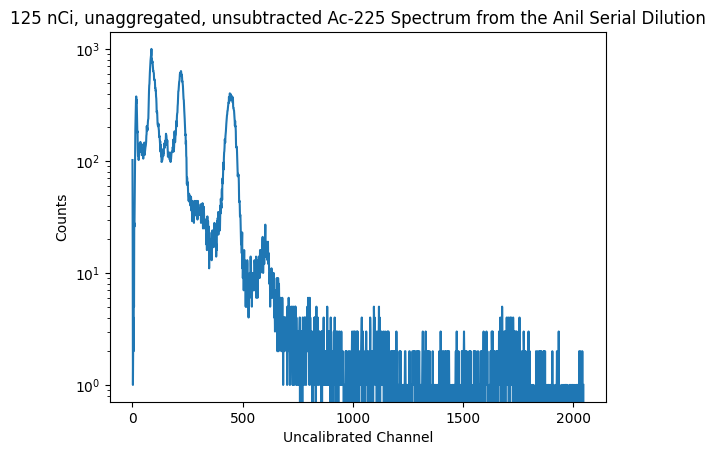

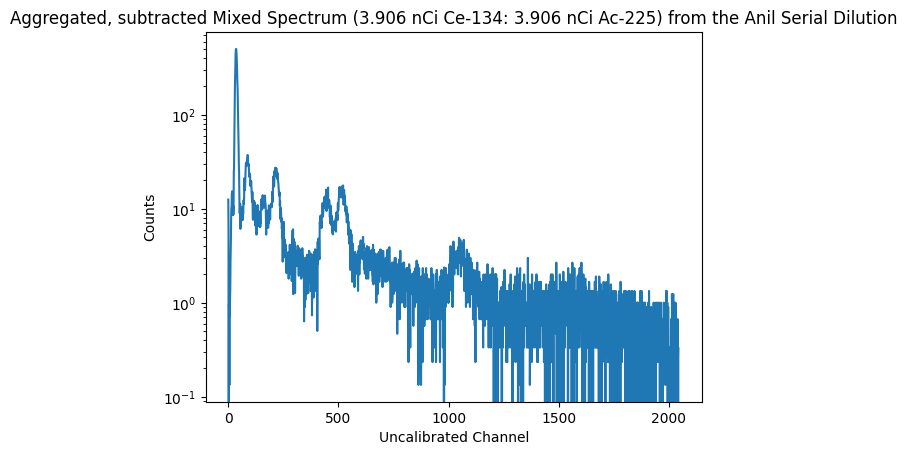

In [34]:
### Just for Viz

#Plotting 125 nCi, unaggregated, unsubtracted Ac-225 Spectrum from the Anil Serial Dilution
example_title = '125 nCi, unaggregated, unsubtracted Ac-225 Spectrum from the Anil Serial Dilution'
example_label = "125_rep2" 
counts = anil_ac_exp.counts_for(example_label)

plt.figure()
plt.plot(counts)
plt.yscale("log")
plt.title(example_title)
plt.xlabel("Uncalibrated Channel")
plt.ylabel("Counts")
plt.show()

### Just for Viz

#Plotting  nCi, unaggregated, unsubtracted Ac-225 Spectrum from the Anil Serial Dilution
example_title = 'Aggregated, subtracted Mixed Spectrum (3.906 nCi Ce-134: 3.906 nCi Ac-225) from the Anil Serial Dilution'
example_label = "3.906:3.906" 
counts = anil_mix_exp_agg_bg_sub.counts_for(example_label)

plt.figure()
plt.plot(counts)
plt.yscale("log")
plt.title(example_title)
plt.xlabel("Uncalibrated Channel")
plt.ylabel("Counts")
plt.show()

In [35]:
### Just for Viz

#Cross-checking with the monolithic notebook, to see if the aggregation and background-subtraction produced the same changes

anil_ce_rec1 = anil_ce_exp_agg.spectrum("3.90625")
print('Anil Ce')
display(anil_ce_rec1.counts)
print(sum(anil_ce_rec1.counts))

anil_ce_rec2 = anil_ce_exp_agg_bg_sub.spectrum("3.90625")
display(anil_ce_rec2.counts)
print(sum(anil_ce_rec2.counts))

print('---')

wenjo_ce_rec1 = wenjo_ce_exp_agg.spectrum("3.125")
print('Wenjo Ce')
display(wenjo_ce_rec1.counts)
print(sum(wenjo_ce_rec1.counts))

wenjo_ce_rec2 = wenjo_ce_exp_agg_bg_sub.spectrum("3.125")
display(wenjo_ce_rec2.counts)
print(sum(wenjo_ce_rec2.counts))

print('---')

anil_ac_rec1 = anil_ac_exp_agg.spectrum("3.90625")
print('Anil Ac')
display(anil_ac_rec1.counts)
print(sum(anil_ac_rec1.counts))

anil_ac_rec2 = anil_ac_exp_agg_bg_sub.spectrum("3.90625")
display(anil_ac_rec2.counts)
print(sum(anil_ac_rec2.counts))

Anil Ce


array([25.        ,  7.        ,  2.66666667, ...,  0.        ,
        1.33333333,  0.33333333])

9238.666666666695


array([15.5       ,  5.        ,  1.16666667, ...,  0.        ,
        1.33333333,  0.23333333])

8995.566666666722
---
Wenjo Ce


...

7214.999999999887
---
Anil Ac


array([14.        ,  2.66666667,  1.        , ...,  0.33333333,
        0.        ,  0.33333333])

3338.6666666667084


array([4.5       , 0.66666667, 0.        , ..., 0.23333333, 0.        ,
       0.23333333])

3137.599999999992


In [36]:
end

NameError: name 'end' is not defined

In [ ]:
### Loading Anil Ce

# anil_ce_sheet_name = 1

# raw_anil_ce_exp = load_experiment_xls(ANIL_CE, 
#     sheet_name=anil_ce_sheet_name,
#     header=None,
#     data_skiprows=19,
#     data_usecols=range(2,2050),
#     engine='calamine')

# anil_ce_activities = [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125]
# anil_ce_n_reps = 3

# anil_ce_labels = [f"{a:g}_rep{r}" for a in anil_ce_activities for r in range(1, anil_ce_n_reps+1)]

# anil_ce_mapping = ExperimentMapping(
#     experiment_id="ANIL_CE_SD", #SD short for Serial Dilution
#     spectra_block="spectra",
#     labels=anil_ce_labels,
#     meta={
#         "activities": anil_ce_activities,
#         "n_reps": anil_ce_n_reps,
#         "label_scheme": "ACT_repN",
#     },
# )

# anil_ce_exp = apply_mapping(raw_anil_ce_exp, anil_ce_mapping)

# anil_ce_exp.experiment_id, anil_ce_exp.counts.shape, len(anil_ce_exp.labels)
# display(anil_ce_exp.labels[:10])
# display(anil_ce_exp)

# store.save_experiment(anil_ce_exp)
# print("Saved:", anil_ce_exp.experiment_id)
# print("Artifact root:", store.root)


anil_ce_exp_agg_bg_sub = subtract_background(
    anil_ce_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',       
    use_embedded_background_if_available=False,
)

store.save_experiment(anil_ce_exp_agg_bg_sub)

print("Saved raw:", anil_ce_exp_agg.experiment_id, anil_ce_exp_agg.counts.shape)
print("Saved agg:", anil_ce_exp_agg_bg_sub.experiment_id, anil_ce_exp_agg_bg_sub.counts.shape)

### Loading Wenjo Ce

# wenjo_ce_sheet_name = 1

# raw_wenjo_ce_exp = load_experiment_xls(WENJO_CE, 
#     sheet_name=wenjo_ce_sheet_name,
#     header=None,
#     data_skiprows=19,
#     data_usecols=range(2,2050),
#     engine='calamine')

# wenjo_ce_activities = [200.0, 100.0, 50.0, 25.0, 12.5, 6.25, 3.125, 1.5625, 0.78125, 0.390625]
# wenjo_ce_n_reps = 2

# wenjo_ce_labels = [f"{a:g}_rep{r}" for a in wenjo_ce_activities for r in range(1, wenjo_ce_n_reps+1)] + [f"0.0_rep{r}" for r in range(1, 11)]

# wenjo_ce_mapping = ExperimentMapping(
#     experiment_id="WENJO_CE_SD", #SD short for Serial Dilution
#     spectra_block="spectra",
#     # samples_are_rows=True,
#     # channel_col_slice=slice(2, 2050),  # CHANGE THIS after checking your sheet
#     labels=labels,
#     meta={
#         "activities": activities,
#         "n_reps": n_reps,
#         "label_scheme": "ACT_repN",
#     },
# )

# wenjo_ce_exp = apply_mapping(raw_wenjo_ce_exp, wenjo_ce_mapping)

# store.save_experiment(wenjo_ce_exp)
# print("Saved:", wenjo_ce_exp.experiment_id)
# print("Artifact root:", store.root)


store.save_experiment(wenjo_ce_exp_agg)
store.save_experiment_array(wenjo_ce_exp_agg.experiment_id, "counts_sd_between", sd_between)
store.save_experiment_array(wenjo_ce_exp_agg.experiment_id, "counts_sd_poisson", sd_poisson)

print("Saved raw:", wenjo_ce_exp.experiment_id, wenjo_ce_exp.counts.shape)
print("Saved agg:", wenjo_ce_exp_agg.experiment_id, wenjo_ce_exp_agg.counts.shape)

wenjo_ce_agg_bkg_counts = wenjo_ce_exp_agg.counts[wenjo_ce_exp_agg.index_of('0')]

wenjo_ce_exp_agg_bg_sub = subtract_background(
    wenjo_ce_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',         
    use_embedded_background_if_available=False,
)

store.save_experiment(wenjo_ce_exp_agg_bg_sub)
print("Saved raw:", wenjo_ce_exp_agg.experiment_id, wenjo_ce_exp_agg.counts.shape)
print("Saved agg:", wenjo_ce_exp_agg_bg_sub.experiment_id, wenjo_ce_exp_agg_bg_sub.counts.shape)

### Loading Anil Ac

# sheet_name = 1

# raw_anil_ac_exp = load_experiment_xls(ANIL_AC, 
#     sheet_name=sheet_name,
#     header=None,
#     data_skiprows=19,
#     data_usecols=range(2,2050),
#     engine='calamine')

# anil_ac_activities = [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125]
# anil_ac_n_reps = 3

# labels = [f"{a:g}_rep{r}" for a in anil_ac_activities for r in range(1, anil_ac_n_reps+1)]

# anil_ac_mapping = ExperimentMapping(
#     experiment_id="ANIL_AC_SD", #SD short for Serial Dilution
#     spectra_block="spectra",
#     # samples_are_rows=True,
#     # channel_col_slice=slice(2, 2050),  # CHANGE THIS after checking your sheet
#     labels=labels,
#     meta={
#         "activities": anil_ac_activities,
#         "n_reps": anil_ac_n_reps,
#         "label_scheme": "ACT_repN",
#     },
# )

store.save_experiment(anil_ac_exp_agg)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_between", sd_between)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_poisson", sd_poisson)

anil_ac_exp = apply_mapping(raw_anil_ac_exp, anil_ac_mapping)

anil_ac_exp.experiment_id, anil_ac_exp.counts.shape, len(anil_ac_exp.labels)

anil_ac_exp.labels[:10]

anil_ac_exp_agg_bg_sub = subtract_background(
    anil_ac_exp_agg,
    bkg_counts=wenjo_ce_agg_bkg_counts,
    suppress_background='auto',         
    use_embedded_background_if_available=False,
)




### Just for Viz

Experiment: ANIL_CE_SD
counts shape: (30, 2048)
min/max counts: 0.0 91217.0
first labels: ['1000_rep1', '1000_rep2', '1000_rep3', '500_rep1', '500_rep2']


C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


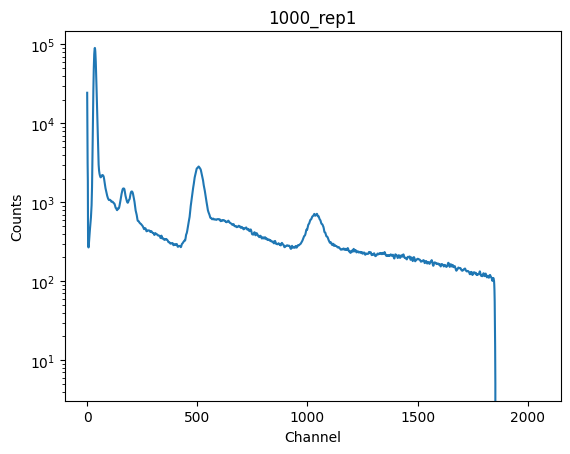

In [ ]:
### Just for viz

print("Experiment:", anil_ce_exp.experiment_id)
print("counts shape:", anil_ce_exp.counts.shape)
print("min/max counts:", np.min(anil_ce_exp.counts), np.max(anil_ce_exp.counts))
print("first labels:", anil_ce_exp.labels[:5])

# quick check: plot one spectrum

i0 = 0
plt.figure()
plt.plot(anil_ce_exp.counts[i0])
plt.yscale("log")
plt.title(anil_ce_exp.labels[i0])
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.show()

anil_ce_exp_raw = store.load_experiment("ANIL_CE_SD")
anil_ce_exp_agg, sd_between, sd_poisson = aggregate_replicates(anil_ce_exp_raw, ddof=1, use_sem=False)

store.save_experiment(anil_ce_exp_agg)
store.save_experiment_array(anil_ce_exp_agg.experiment_id, "counts_sd_between", sd_between)
store.save_experiment_array(anil_ce_exp_agg.experiment_id, "counts_sd_poisson", sd_poisson)

print("Saved raw:", anil_ce_exp.experiment_id, anil_ce_exp.counts.shape)
print("Saved agg:", anil_ce_exp_agg.experiment_id, anil_ce_exp_agg.counts.shape)

display(anil_ce_exp_agg)


Experiment: ANIL_CE_SD__agg
counts shape: (10, 2048)
min/max counts: 0.0 90514.66666666667
first labels: ['1.95312', '3.90625', '7.8125', '15.625', '31.25']


array([24877.66666667,  6596.66666667,  3146.        , ...,
           0.        ,     0.        ,     0.        ])

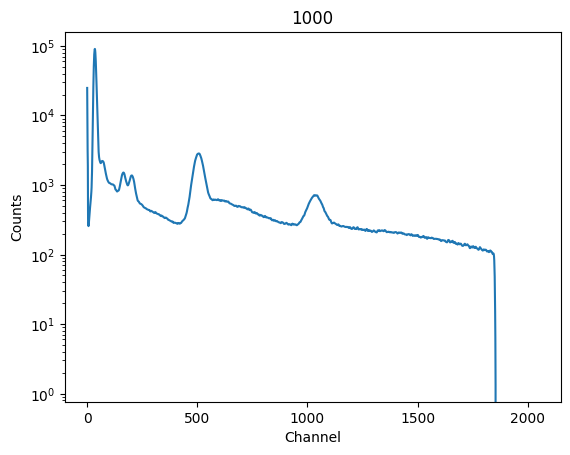

In [ ]:
### Just for viz

print("Experiment:", anil_ce_exp_agg.experiment_id)
print("counts shape:", anil_ce_exp_agg.counts.shape)
print("min/max counts:", np.min(anil_ce_exp_agg.counts), np.max(anil_ce_exp_agg.counts))
print("first labels:", anil_ce_exp_agg.labels[:5])

# quick check: plot one spectrum

i0 = 9
display(anil_ce_exp_agg.counts[i0])

plt.figure()
plt.plot(anil_ce_exp_agg.counts[i0])
plt.yscale("log")
plt.title(anil_ce_exp_agg.labels[i0])
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.show()

### Wenjo Ce

### Anil Ac

In [ ]:
# sheet_name = 1

# anil_ac_sheet = read_excel_sheet(ANIL_AC, 
#     sheet_name=sheet_name,
#     header=None,
#     skiprows=19,
#     usecols=range(2,2050),
#     engine='calamine')

# display(anil_ac_sheet)

['1000_rep1',
 '1000_rep2',
 '1000_rep3',
 '500_rep1',
 '500_rep2',
 '500_rep3',
 '250_rep1',
 '250_rep2',
 '250_rep3',
 '125_rep1']

In [ ]:
anil_ac_exp

Experiment(experiment_id='ANIL_AC_SD', counts=array([[1.281e+03, 7.600e+01, 4.200e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.325e+03, 9.500e+01, 3.600e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.379e+03, 9.200e+01, 3.700e+01, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [1.100e+01, 4.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.300e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [7.000e+00, 1.000e+00, 3.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00]]), labels=['1000_rep1', '1000_rep2', '1000_rep3', '500_rep1', '500_rep2', '500_rep3', '250_rep1', '250_rep2', '250_rep3', '125_rep1', '125_rep2', '125_rep3', '62.5_rep1', '62.5_rep2', '62.5_rep3', '31.25_rep1', '31.25_rep2', '31.25_rep3', '15.625_rep1', '15.625_rep2', '15.625_rep3', '7.8125_rep1', '7.8125_rep2', '7.8125_rep3', '3.90625_rep1', '3.90625_rep2', '3.90625_rep3', '1.95312_rep1', '1.95312_rep2', '1.953

Experiment: ANIL_AC_SD
counts shape: (30, 2048)
min/max counts: 0.0 7512.0
first labels: ['1000_rep1', '1000_rep2', '1000_rep3', '500_rep1', '500_rep2']


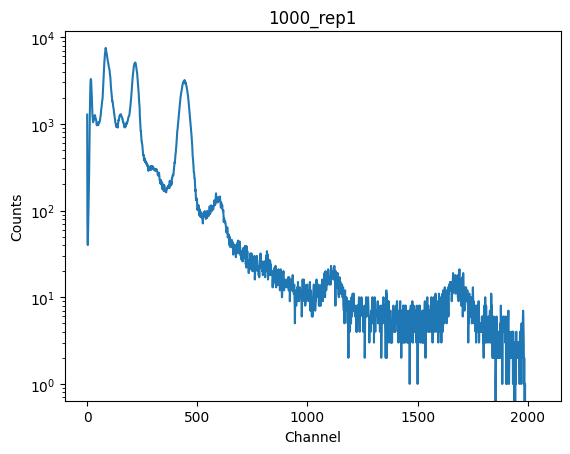

In [ ]:
print("Experiment:", anil_ac_exp.experiment_id)
print("counts shape:", anil_ac_exp.counts.shape)
print("min/max counts:", np.min(anil_ac_exp.counts), np.max(anil_ac_exp.counts))
print("first labels:", anil_ac_exp.labels[:5])

# quick check: plot one spectrum

i0 = 0
plt.figure()
plt.plot(anil_ac_exp.counts[i0])
plt.yscale("log")
plt.title(anil_ac_exp.labels[i0])
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.show()


In [ ]:
store.save_experiment(anil_ac_exp)
print("Saved:", anil_ac_exp.experiment_id)
print("Artifact root:", store.root)

Saved: ANIL_AC_SD
Artifact root: C:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\artifacts


In [ ]:
anil_ac_exp_raw = store.load_experiment("ANIL_AC_SD")
anil_ac_exp_agg, sd_between, sd_poisson = aggregate_replicates(anil_ac_exp_raw, ddof=1, use_sem=False)

store.save_experiment(anil_ac_exp_agg)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_between", sd_between)
store.save_experiment_array(anil_ac_exp_agg.experiment_id, "counts_sd_poisson", sd_poisson)

In [ ]:
print("Saved raw:", anil_ac_exp.experiment_id, anil_ac_exp.counts.shape)
print("Saved agg:", anil_ac_exp_agg.experiment_id, anil_ac_exp_agg.counts.shape)

Saved raw: ANIL_AC_SD (30, 2048)
Saved agg: ANIL_AC_SD__agg (10, 2048)


In [ ]:
anil_ac_exp_agg

Experiment(experiment_id='ANIL_AC_SD__agg', counts=array([[1.03333333e+01, 1.66666667e+00, 1.33333333e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.40000000e+01, 2.66666667e+00, 1.00000000e+00, ...,
        3.33333333e-01, 0.00000000e+00, 3.33333333e-01],
       [2.16666667e+01, 3.66666667e+00, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.21000000e+02, 3.26666667e+01, 9.33333333e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.03666667e+02, 4.86666667e+01, 1.90000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.32833333e+03, 8.76666667e+01, 3.83333333e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]), labels=['1.95312', '3.90625', '7.8125', '15.625', '31.25', '62.5', '125', '250', '500', '1000'], weights=None, meta={'mapping_meta': {'activities': [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953125], 'l

In [ ]:
np.shape(sd_between)

(10, 2048)

In [ ]:
# print("Experiment:", anil__exp_agg.experiment_id)
# print("counts shape:", anil__exp_agg.counts.shape)
# print("min/max counts:", np.min(anil__exp_agg.counts), np.max(anil__exp_agg.counts))
# print("first labels:", anil__exp_agg.labels[:5])

# # quick check: plot one spectrum


# i0 = 9
# display(anil__exp_agg.counts[i0])

# plt.figure()
# plt.plot(anil__exp_agg.counts[i0])
# plt.yscale("log")
# plt.title(anil__exp_agg.labels[i0])
# plt.xlabel("Channel")
# plt.ylabel("Counts")
# plt.show()

In [ ]:
anil_ac_exp_agg_bg_sub

Experiment(experiment_id='ANIL_AC_SD__agg__bkgsub', counts=array([[8.33333333e-01, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.50000000e+00, 6.66666667e-01, 0.00000000e+00, ...,
        2.33333333e-01, 0.00000000e+00, 2.33333333e-01],
       [1.21666667e+01, 1.66666667e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.11500000e+02, 3.06666667e+01, 7.83333333e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.94166667e+02, 4.66666667e+01, 1.75000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.31883333e+03, 8.56666667e+01, 3.68333333e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]), labels=['1.95312', '3.90625', '7.8125', '15.625', '31.25', '62.5', '125', '250', '500', '1000'], weights=None, meta={'mapping_meta': {'activities': [1000, 500.0, 250.0, 125.0, 62.5, 31.25, 15.625, 7.8125, 3.90625, 1.953

In [ ]:
lab = anil_ac_exp.labels[0]
y = anil_ac_exp.counts_for(lab)          
y_list = anil_ac_exp.counts_for(lab, as_list=True) 


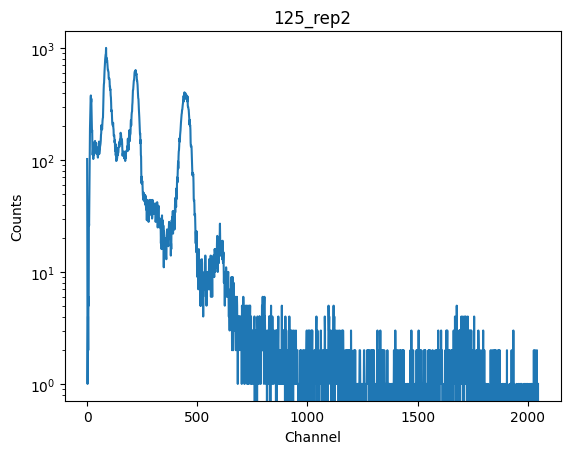

In [ ]:
# rec = anil_ac_exp.spectrum("125_rep1")
# print(rec.experiment_id, rec.label, rec.counts.shape, rec.weight)


array([14.        ,  2.66666667,  1.        , ...,  0.33333333,
        0.        ,  0.33333333])

3338.6666666667084


array([4.5       , 0.66666667, 0.        , ..., 0.23333333, 0.        ,
       0.23333333])

3137.599999999992
